In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

fish = pd.read_csv('Fish.csv')

# 입력(무게·길이·대각선·높이·너비), 타깃(종)
fish_input = fish[['Weight', 'Length2', 'Length3', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled  = ss.transform(test_input)

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.predict_proba(test_scaled[:5]))

[[0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


In [34]:
from sklearn.linear_model import LogisticRegression

bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

sample = train_bream_smelt[0]

In [35]:
lr = LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)

print(lr.predict([sample]))
print(lr.predict_proba([sample]))

['Bream']
[[0.99760007 0.00239993]]


In [36]:
# 결정함수
decisions = lr.decision_function(train_bream_smelt[0:5])

In [37]:
from scipy.special import expit
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


클래스 순서: ['Bream' 'Smelt']
결정함수 값: [-6.02991358]
시그모이드 적용 결과: [0.00239993]
예측 클래스: ['Bream']
predict_proba 결과: [[0.99760007 0.00239993]]


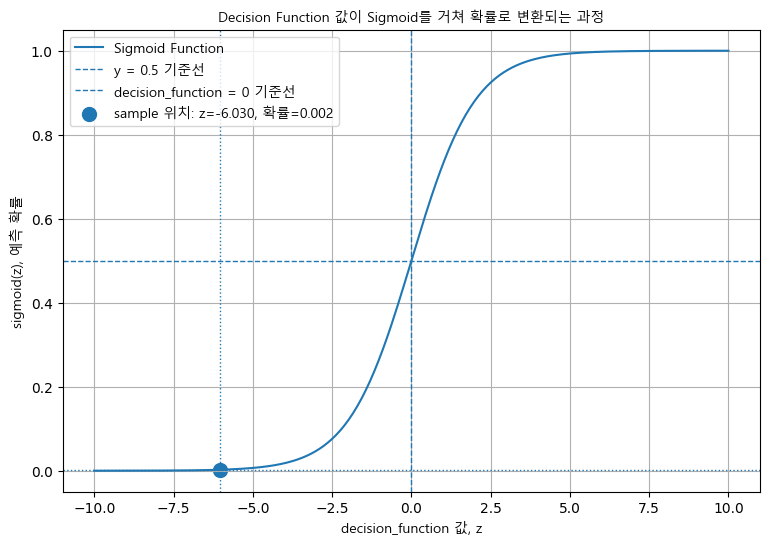

In [38]:
# 시각화 결정 경계, 시그모이드 함수 시각화

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy.special import expit
from sklearn.linear_model import LogisticRegression

# =========================
# 1. 한글 폰트 설정
# =========================
# Windows 환경
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = FontProperties(fname=font_path)

# =========================
# 2. Bream / Smelt 데이터만 선택
# =========================
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')

train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

# =========================
# 3. 로지스틱 회귀 모델 학습
# =========================
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

# =========================
# 4. 예측할 sample 선택
# =========================
# Bream / Smelt 데이터 중 첫 번째 샘플 사용
sample = train_bream_smelt[0]

# =========================
# 5. decision_function 값 계산
# =========================
decision_value = lr.decision_function([sample])

# =========================
# 6. decision_function 값에 시그모이드 적용
# =========================
sample_probability = expit(decision_value)

# =========================
# 7. 예측 결과 확인
# =========================
predicted_class = lr.predict([sample])
predicted_proba = lr.predict_proba([sample])

print("클래스 순서:", lr.classes_)
print("결정함수 값:", decision_value)
print("시그모이드 적용 결과:", sample_probability)
print("예측 클래스:", predicted_class)
print("predict_proba 결과:", predicted_proba)

# =========================
# 8. 시그모이드 곡선용 x, y 값 생성
# =========================
z_values = np.linspace(-10, 10, 300)
sigmoid_values = expit(z_values)

# =========================
# 9. 시각화
# =========================
plt.figure(figsize=(9, 6))

# 시그모이드 곡선
plt.plot(z_values, sigmoid_values, label="Sigmoid Function")

# 기준선 y = 0.5
plt.axhline(y=0.5, linestyle="--", linewidth=1, label="y = 0.5 기준선")

# 기준선 x = 0
plt.axvline(x=0, linestyle="--", linewidth=1, label="decision_function = 0 기준선")

# sample 위치 표시
plt.scatter(
    decision_value[0],
    sample_probability[0],
    s=100,
    label=f"sample 위치: z={decision_value[0]:.3f}, 확률={sample_probability[0]:.3f}"
)

# sample 보조선
plt.axvline(x=decision_value[0], linestyle=":", linewidth=1)
plt.axhline(y=sample_probability[0], linestyle=":", linewidth=1)

# 제목, 축 이름
title = plt.title("Decision Function 값이 Sigmoid를 거쳐 확률로 변환되는 과정")
title.set_fontproperties(font_prop)

xlabel = plt.xlabel("decision_function 값, z")
xlabel.set_fontproperties(font_prop)

ylabel = plt.ylabel("sigmoid(z), 예측 확률")
ylabel.set_fontproperties(font_prop)

# 범례 한글 폰트 적용
legend = plt.legend()
for text in legend.get_texts():
    text.set_fontproperties(font_prop)

plt.grid(True)
plt.show()

# 다중분류
 - SoftMax 함수
    - e(자연 로그의 밑) 지수 함수를 적용
    - 정규화 -> 모든 확률의 합은 100퍼. 하지만 가장 큰 점수를 극대화 시키는 함수


--------------------------------------

In [39]:
lr = LogisticRegression(C=20, max_iter = 1000)
# C 규제의 역수 클수록 자유도가 높다
# max_iter는 한번에 결정경계를 못 찾기 때문에 반복학습을 한다(경사하강법)
lr.fit(train_scaled, train_target)

print(lr.classes_)

proba = lr.predict_proba(test_scaled[:3])
print(proba.round(3))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]]


In [40]:
decision = lr.decision_function(test_scaled[:5])
print(decision.shape)

(5, 7)


In [41]:
# g(z)
from scipy.special import softmax
proba_from_softmax = softmax(decision, axis=1)
proba_from_softmax.round(3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [42]:
import pandas as pd

proba_df = pd.DataFrame(lr.predict_proba(test_scaled.round(3)), columns=lr.classes_)
proba_df

,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
0,7.121809e-06,1.350578e-02,8.424327e-01,3.043254e-04,1.344073e-01,6.787221e-03,2.555608e-03
1,7.050702e-09,2.604436e-03,4.405420e-02,3.306887e-05,7.382248e-03,9.459207e-01,5.326540e-06
2,1.863853e-05,2.787371e-06,3.382459e-02,9.344961e-01,1.527361e-02,1.635453e-02,2.974957e-05
3,1.088220e-02,3.389329e-02,3.048458e-01,6.444969e-03,5.674446e-01,7.244252e-05,7.641662e-02
4,4.464344e-06,3.670492e-04,9.043332e-01,2.354751e-03,8.913434e-02,2.467525e-03,1.338630e-03
5,9.993990e-01,2.298543e-04,1.974541e-09,3.985019e-10,1.322715e-07,2.060279e-19,3.710178e-04
6,6.821510e-10,1.081183e-03,5.015323e-02,8.530083e-06,3.817482e-03,9.449374e-01,2.176369e-06
7,1.260003e-03,7.459364e-03,3.202820e-01,1.421641e-02,6.379197e-01,1.016175e-03,1.784637e-02
8,1.171238e-04,1.898081e-03,8.027543e-01,2.108734e-03,1.814632e-01,1.892927e-04,1.146928e-02
9,3.367714e-06,3.213118e-13,2.250087e-02,9.774936e-01,2.514620e-07,3.753577e-12,1.927207e-06


In [43]:
# 평가
lr.score(test_scaled, test_target) # 정확도 92.5%

0.925

In [44]:
from sklearn.metrics import  confusion_matrix

y_true = [1,0,1,1,0,1,0,0]
y_pred = [1,0,0,1,0,1,0,1]

confusion_matrix(y_true, y_pred)

array([[3, 1],
       [1, 3]])

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



타이타닉 데이터로 평가지표 확인

In [46]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [47]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [48]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 기본 전처리
titanic_clean = titanic[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()

# 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex'], drop_first=True)

X = titanic_clean.drop('survived', axis=1).values
y = titanic_clean['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y)  # stratify로 불균형 비율 유지

ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))

생존: 290 사망: 424
생존 비율: 0.406


In [49]:
# 학습
lr = LogisticRegression()
lr.fit(X_train_s,y_train) # 학습
y_pred = lr.predict(X_test_s) # 예측
lr.score(X_test_s, y_test)# 평가

0.7932960893854749

In [50]:
confusion_matrix(y_test, y_pred)

array([[87, 19],
       [18, 55]])

In [51]:
print(confusion_matrix(y_test, y_pred)) # 혼돈행렬
print(classification_report(y_test, y_pred)) # 평가지표

[[87 19]
 [18 55]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       106
           1       0.74      0.75      0.75        73

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [52]:
# ROC AUC 점수
from sklearn.metrics import roc_auc_score
y_score = lr.predict_proba(X_test_s)[:,1] # 생존확률만 확인, 차원축소
print(y_score[:3])
roc_auc_score(y_test, y_score) # AUC score : 0.86

[0.08897927 0.20280058 0.09118474]


0.8634660118893771

In [59]:
y_score_30 = (y_score >= 0.3).astype(int)
print(classification_report(y_test, y_score_30,target_names=['사망', '생존']))

              precision    recall  f1-score   support

          사망       0.85      0.69      0.76       106
          생존       0.65      0.82      0.72        73

    accuracy                           0.74       179
   macro avg       0.75      0.76      0.74       179
weighted avg       0.77      0.74      0.75       179



SGD 확률적 경사하강법

In [60]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', random_state=42)

train_score, test_score = [], []
classes = np.unique(train_target)

for _ in range(300):
    sc.partial_fit(train_scaled, train_target,
                   classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

In [61]:
train_score

[0.5294117647058824,
 0.6218487394957983,
 0.6386554621848739,
 0.7142857142857143,
 0.7142857142857143,
 0.7394957983193278,
 0.7058823529411765,
 0.7226890756302521,
 0.7563025210084033,
 0.8067226890756303,
 0.8151260504201681,
 0.8487394957983193,
 0.8403361344537815,
 0.8571428571428571,
 0.8739495798319328,
 0.8571428571428571,
 0.8571428571428571,
 0.8739495798319328,
 0.8739495798319328,
 0.8739495798319328,
 0.8907563025210085,
 0.8739495798319328,
 0.8739495798319328,
 0.8823529411764706,
 0.8907563025210085,
 0.8907563025210085,
 0.8739495798319328,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8907563025210085,
 0.8907563025210085,
 0.8823529411764706,
 0.907563025210084,
 0.8991596638655462,
 0.9243697478991597,
 0.907563025210084,
 0.9243697478991597,
 0.9159663865546218,
 0.9159663865546218,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.932773109243

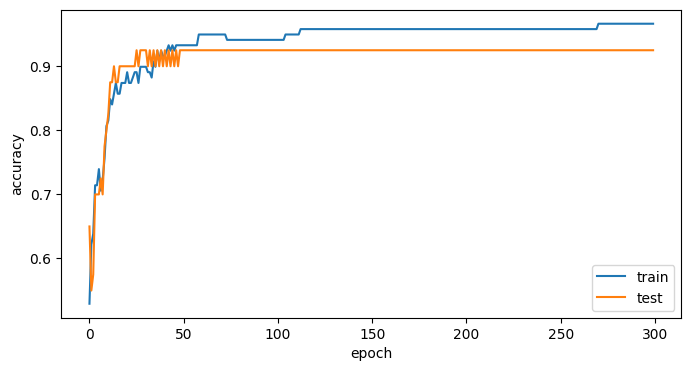

In [62]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_score, label='train')
plt.plot(test_score,  label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()